### Introduction

The hotel industry relies heavily on reservations to plan room availability, manage operations, and maximize revenue. However, booking cancellations can create significant challenges, particularly when cancelled rooms remain unoccupied and cannot be resold in time. Understanding the factors associated with cancellations can therefore help hotels make better decisions and reduce potential revenue losses.

In this project, historical hotel booking data will be explored to identify patterns and factors associated with reservation cancellations. Exploratory Data Analysis (EDA) will be used to investigate cancellation rates across different family sizes, times of the year, booking lead times, and other customer and reservation characteristics. A binary classification model will then be developed to predict whether a hotel reservation is likely to be cancelled or not.

The goal is to demonstrate how machine learning can be applied to a practical business problem and provide insights that could help hotel management anticipate cancellations and improve booking and room-management strategies.

### Objectives

The main objectives of this project are to:

1. Explore the characteristics and patterns within the hotel booking dataset.
2. Investigate the factors associated with hotel booking cancellations.
3. Analyze cancellation rates across different family sizes and times of the year.
4. Examine the relationship between booking lead time and cancellation likelihood.
5. Clean and preprocess the dataset for machine learning.
6. Engineer and select relevant features for predicting booking cancellations.
7. Develop and compare different binary classification models.
8. Evaluate model performance using appropriate classification metrics.
9. Identify the most important factors influencing cancellation predictions.
10. Select the best-performing model for predicting hotel booking cancellations and discuss its potential business applications.

### Import the necessary python libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

sns.set()

In [2]:
hotel_df = pd.read_csv('hotel_bookings.csv')
hotel_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
hotel_df['reservation_status'].value_counts()

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

### Getting the statistical summary of the data

In [4]:
hotel_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [5]:
hotel_df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [6]:
hotel_df.describe(include='object')

C:\Users\Itz_Ebuka\AppData\Local\Temp\ipykernel_8312\2463892448.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  hotel_df.describe(include='object')


,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


There are categorical columns which we need to deal with before using it for the classification model

In [7]:
# Checking for missing values
hotel_df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

3 columns have missing values which we will have to deal with.

In [8]:
# Checking for duplicates
hotel_df.duplicated().sum()

np.int64(31994)

There are about 31,994 duplicated values. It needs to be dealt with.

### Data Cleaning/Preprocessing

#### Dealing with the missing values

In [9]:
# For the children column: filling wth the mean
hotel_df['children'] = hotel_df['children'].fillna(hotel_df['children'].mean())

In [10]:
# For the country column: Since country is categorical, replacing the missing values with "Unknown"
hotel_df['country'] = hotel_df['country'].fillna('Unknown')

In [11]:
# For the agent column: replace the missing values with 0 which can represent "No Agent/Unknown Agent"

hotel_df['agent'] = hotel_df['agent'].fillna(0)

In [12]:
# For the company column: the column will be dropped as over 90% of its value is missing
hotel_df.drop('company', axis = 1, inplace = True)

In [13]:
hotel_df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

All the missing values have been handled.

In [14]:
# Dealing with th duplicated values
hotel_df = hotel_df.drop_duplicates()

In [15]:
hotel_df.duplicated().sum()

np.int64(0)

In [16]:
hotel_df.info()

<class 'pandas.DataFrame'>
Index: 87389 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87389 non-null  str    
 1   is_canceled                     87389 non-null  int64  
 2   lead_time                       87389 non-null  int64  
 3   arrival_date_year               87389 non-null  int64  
 4   arrival_date_month              87389 non-null  str    
 5   arrival_date_week_number        87389 non-null  int64  
 6   arrival_date_day_of_month       87389 non-null  int64  
 7   stays_in_weekend_nights         87389 non-null  int64  
 8   stays_in_week_nights            87389 non-null  int64  
 9   adults                          87389 non-null  int64  
 10  children                        87389 non-null  float64
 11  babies                          87389 non-null  int64  
 12  meal                            87389 non-null 

All the duplicated values have been removed therefore the data set reduced from  **119,390** to **87,389** rows of data.

### Exploratory Data Analysis

Let's carry out some quick visualizations to have an understanding of the data set.

#### i. Overall Cancellation Rate

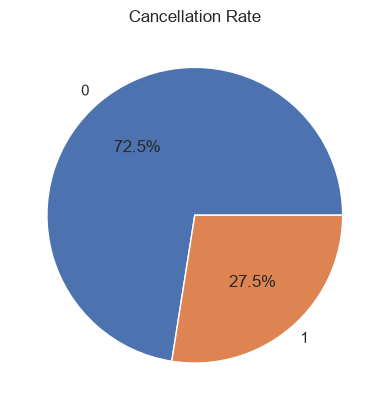

In [17]:
rate_counts = hotel_df['is_canceled'].value_counts()

plt.pie(rate_counts, labels = rate_counts.index, autopct='%1.1f%%')
plt.title('Cancellation Rate')
plt.show()

The overall cancellation rate is 27.5%, meaning that approximately 1 in every 4 hotel bookings was cancelled, while 72.5% were successfully retained. This relatively high cancellation rate highlights the importance of developing a predictive model that can identify bookings with a higher likelihood of cancellation and help the hotel take proactive measures.

#### ii. Family size vs Cancellation Rate

Which family sizes are associated with the highest cancellation rate?

In [18]:
# Create the family size column:
hotel_df['family_size'] = (hotel_df['adults'] + hotel_df['children'] + hotel_df['babies'])

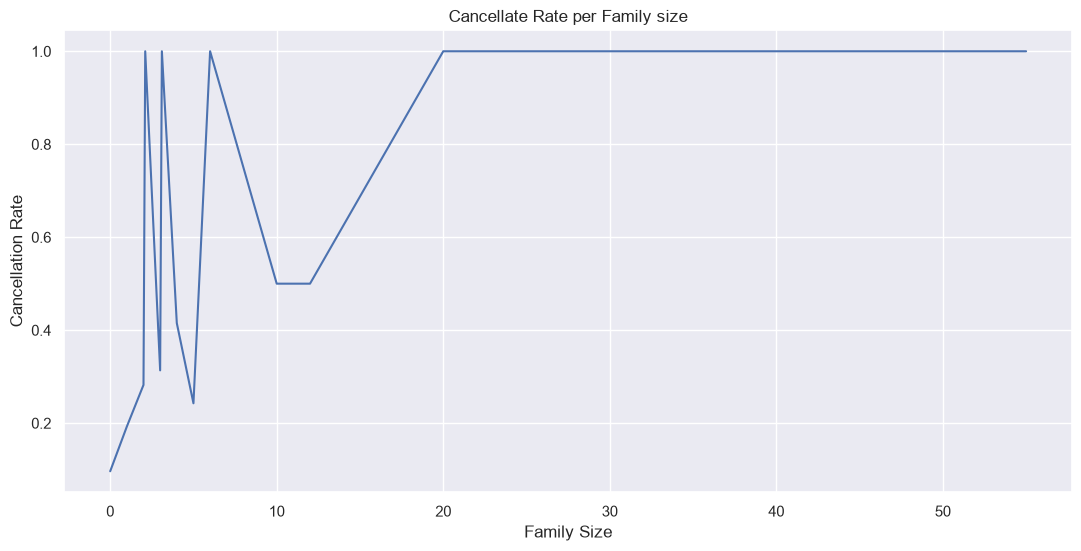

In [19]:
# family size by cancellation rate
family_cancel_rate = hotel_df.groupby('family_size')['is_canceled'].mean()

plt.figure(figsize=(13, 6))
plt.plot(family_cancel_rate)
plt.xlabel('Family Size')
plt.ylabel('Cancellation Rate')
plt.title('Cancellate Rate per Family size')
plt.show()

The family-size analysis shows substantial variation in cancellation rates, with some larger family-size categories showing cancellation rates close to 100%. However, these results should be interpreted with caution because very large family sizes are likely represented by only a small number of bookings. Therefore, the extreme cancellation rates in those groups may not be statistically reliable. A better approach would be to focus on family-size categories with sufficient observations or group larger families into broader categories before drawing conclusions.

#### Cancellation Rate by Month

To understand the cancellation rates during different times of the year

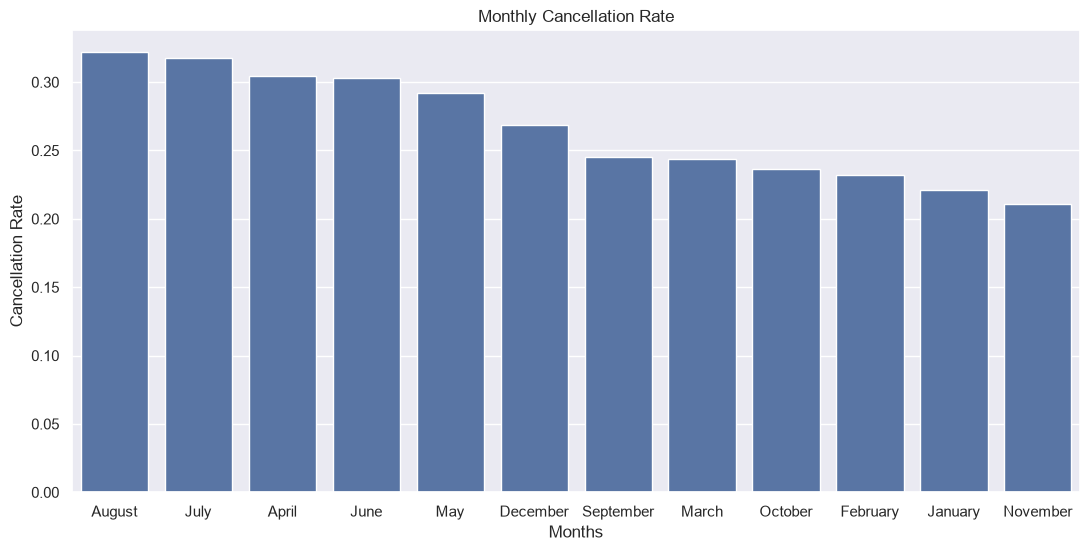

In [20]:
# Focusing on the months in the year
monthly_cancel_rate = hotel_df.groupby('arrival_date_month')['is_canceled'].mean().sort_values(ascending=False).index

plt.figure(figsize = (13, 6))
sns.barplot(hotel_df, x='arrival_date_month', y='is_canceled', order = monthly_cancel_rate, errorbar=None)
plt.xlabel('Months')
plt.ylabel('Cancellation Rate')
plt.title('Monthly Cancellation Rate')
plt.show()

Cancellation rates vary considerably across the year. August recorded the highest cancellation rate at approximately 32%, closely followed by July, while November had the lowest rate at approximately 21%. This indicates that the time of year may influence cancellation behavior, with bookings during certain months being more susceptible to cancellation. This seasonal pattern could therefore provide useful information for predicting cancellation risk.

#### iv. Lead Time vs Cancellation

Are bookings with longer lead times more likely to result in cancellation?

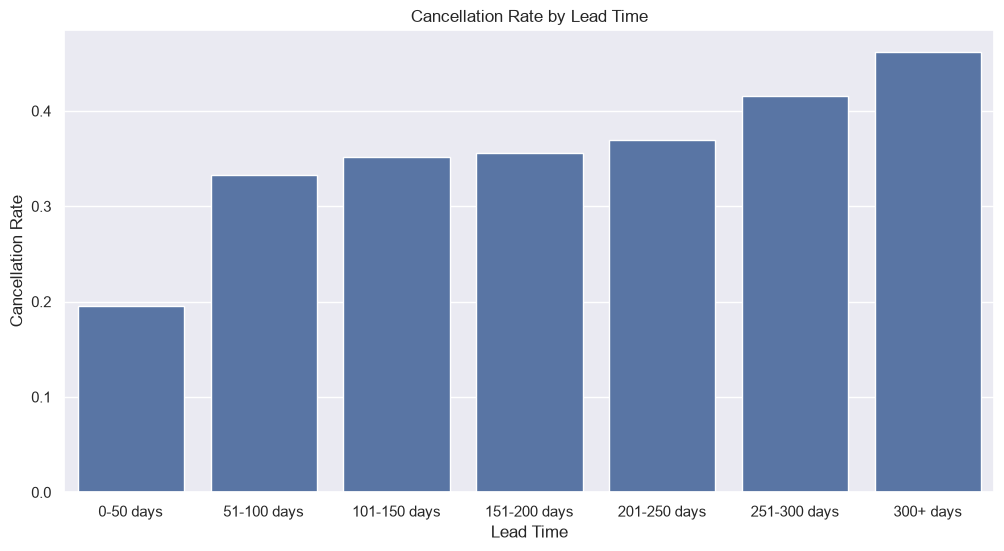

In [21]:
# Group the lead times
bins = [0, 50, 100, 150, 200, 250, 300, float('inf')]
labels = ['0-50 days', '51-100 days', '101-150 days', '151-200 days', '201-250 days', '251-300 days','300+ days']

hotel_df['lead_time_group'] = pd.cut(
    hotel_df['lead_time'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Calculate the mean cancellation rate
lead_time_cancel_rate = (hotel_df.groupby('lead_time_group', observed=True)['is_canceled'].mean().reset_index())

# Visualize
plt.figure(figsize=(12, 6))
sns.barplot(data=lead_time_cancel_rate, x='lead_time_group', y='is_canceled')

plt.title('Cancellation Rate by Lead Time')
plt.xlabel('Lead Time')
plt.ylabel('Cancellation Rate')
plt.show()

There is a clear positive relationship between lead time and cancellation rate. Bookings made 0–50 days before arrival had the lowest cancellation rate at approximately 19.5%, while bookings made more than 300 days in advance had the highest rate at about 46%. Overall, the cancellation rate generally increases as the time between booking and arrival becomes longer. This suggests that longer lead times are associated with a greater likelihood of cancellation, making lead_time an important variable for the predictive model.

### Feature Engineering

In [22]:
# Creating new features fromm existing ones
# 1. Total Guests:
hotel_df['total_guests'] = (hotel_df['adults'] +  hotel_df['children'] + hotel_df['babies'])

# 2. Total Stay Duration:
hotel_df['total_stay_duration'] = (hotel_df['stays_in_weekend_nights'] + hotel_df['stays_in_week_nights'])

As we have created some new features, we will also need to remove some certain features in the data set

In [23]:
hotel_df.info()

<class 'pandas.DataFrame'>
Index: 87389 entries, 0 to 119389
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   hotel                           87389 non-null  str     
 1   is_canceled                     87389 non-null  int64   
 2   lead_time                       87389 non-null  int64   
 3   arrival_date_year               87389 non-null  int64   
 4   arrival_date_month              87389 non-null  str     
 5   arrival_date_week_number        87389 non-null  int64   
 6   arrival_date_day_of_month       87389 non-null  int64   
 7   stays_in_weekend_nights         87389 non-null  int64   
 8   stays_in_week_nights            87389 non-null  int64   
 9   adults                          87389 non-null  int64   
 10  children                        87389 non-null  float64 
 11  babies                          87389 non-null  int64   
 12  meal                            8

Now we need to perfrom **Feature Selection**. There are 35 columns and of which it is not all that is a potential predition for our target variable.

In [24]:
# Dropping non-useful columns:
columns_to_drop = ['required_car_parking_spaces', 'reserved_room_type', 'total_of_special_requests', 'lead_time_group',
                  'agent', 'reserved_room_type', 'assigned_room_type', 'previous_bookings_not_canceled', 'country', 'reservation_status_date',
                  'days_in_waiting_list', 'stays_in_weekend_nights', 'arrival_date_week_number', 'stays_in_week_nights', 'arrival_date_day_of_month',
                  'adults', 'children', 'babies', 'reservation_status', 'reservation_status_date']

hotel_df = hotel_df.drop(columns = columns_to_drop)

In [25]:
hotel_df.info()

<class 'pandas.DataFrame'>
Index: 87389 entries, 0 to 119389
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   hotel                   87389 non-null  str    
 1   is_canceled             87389 non-null  int64  
 2   lead_time               87389 non-null  int64  
 3   arrival_date_year       87389 non-null  int64  
 4   arrival_date_month      87389 non-null  str    
 5   meal                    87389 non-null  str    
 6   market_segment          87389 non-null  str    
 7   distribution_channel    87389 non-null  str    
 8   is_repeated_guest       87389 non-null  int64  
 9   previous_cancellations  87389 non-null  int64  
 10  booking_changes         87389 non-null  int64  
 11  deposit_type            87389 non-null  str    
 12  customer_type           87389 non-null  str    
 13  adr                     87389 non-null  float64
 14  family_size             87389 non-null  float64
 15  

Now that we have selected some predictor columns, we can now move on to encode the categorical columns in the data set.

In [26]:
le = LabelEncoder()

# Loop through all columns that contain text data types
for col in hotel_df.columns:
    if hotel_df[col].dtype == "str":
        hotel_df[col] = le.fit_transform(hotel_df[col])

In [27]:
hotel_df.info()

<class 'pandas.DataFrame'>
Index: 87389 entries, 0 to 119389
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   hotel                   87389 non-null  int64  
 1   is_canceled             87389 non-null  int64  
 2   lead_time               87389 non-null  int64  
 3   arrival_date_year       87389 non-null  int64  
 4   arrival_date_month      87389 non-null  int64  
 5   meal                    87389 non-null  int64  
 6   market_segment          87389 non-null  int64  
 7   distribution_channel    87389 non-null  int64  
 8   is_repeated_guest       87389 non-null  int64  
 9   previous_cancellations  87389 non-null  int64  
 10  booking_changes         87389 non-null  int64  
 11  deposit_type            87389 non-null  int64  
 12  customer_type           87389 non-null  int64  
 13  adr                     87389 non-null  float64
 14  family_size             87389 non-null  float64
 15  

All categorical columns have been encoded.

### Splitting the data into training and test sets

In [28]:
# Features
X = hotel_df.drop('is_canceled', axis = 1)

# Target
y = hotel_df['is_canceled']

In [29]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [30]:
print(X.shape, X_train.shape, X_valid.shape)

(87389, 16) (69911, 16) (17478, 16)


### Scaling the numerical features

In [31]:
scaler = StandardScaler()

In [32]:
X_train_scaled = scaler.fit_transform(X_train)

In [33]:
X_valid_scaled = scaler.transform(X_valid)

In [34]:
X_train_scaled

array([[-0.79840572, -0.19664328,  1.14962405, ..., -0.02998136,
        -0.02998136,  0.49311534],
       [-0.79840572, -0.74274262, -1.76740224, ..., -0.02998136,
        -0.02998136, -0.95190396],
       [-0.79840572,  2.48737691,  1.14962405, ..., -0.02998136,
        -0.02998136,  0.13186052],
       ...,
       [-0.79840572, -0.76598089,  1.14962405, ..., -0.02998136,
        -0.02998136,  0.13186052],
       [ 1.25249604, -0.92864878, -1.76740224, ..., -0.02998136,
        -0.02998136, -0.95190396],
       [ 1.25249604, -0.92864878, -0.3088891 , ..., -1.27302328,
        -1.27302328, -0.95190396]], shape=(69911, 16))

In [35]:
X_valid_scaled

array([[-7.98405719e-01, -8.93791379e-01, -3.08889097e-01, ...,
        -2.99813614e-02, -2.99813614e-02, -9.51903956e-01],
       [-7.98405719e-01,  8.82017845e-04, -1.76740224e+00, ...,
        -1.27302328e+00, -1.27302328e+00, -5.90649132e-01],
       [ 1.25249604e+00,  1.86788178e-01,  1.14962405e+00, ...,
        -1.27302328e+00, -1.27302328e+00,  1.21562499e+00],
       ...,
       [-7.98405719e-01,  1.52298871e+00,  1.14962405e+00, ...,
        -2.99813614e-02, -2.99813614e-02,  1.31860517e-01],
       [-7.98405719e-01,  2.27823248e+00, -3.08889097e-01, ...,
        -2.99813614e-02, -2.99813614e-02, -2.29394307e-01],
       [ 1.25249604e+00,  2.46413864e+00,  1.14962405e+00, ...,
        -1.27302328e+00, -1.27302328e+00,  8.44072148e+00]],
      shape=(17478, 16))

### Building the Models

#### Logistic Regression Model

In [36]:
# Create an instance of the model
log_model = LogisticRegression()

In [37]:
# Fit the model
log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [38]:
# Making predictions on the training set
log_model_training_pred = log_model.predict(X_train_scaled)

In [39]:
# Evaluate the model performance on the training set
print('Logistic Regression Training Accuracy: ', accuracy_score(y_train, log_model_training_pred))
print('\n')
print('Logistic Regression Training classification report:')
print(classification_report(y_train, log_model_training_pred))

Logistic Regression Training Accuracy:  0.7443749910600621


Logistic Regression Training classification report:
              precision    recall  f1-score   support

           0       0.75      0.97      0.85     50585
           1       0.66      0.15      0.25     19326

    accuracy                           0.74     69911
   macro avg       0.71      0.56      0.55     69911
weighted avg       0.73      0.74      0.68     69911



In [40]:
# Making predictions on the test set
log_model_test_pred = log_model.predict(X_valid_scaled)

In [41]:
# Evaluate the model performance on the test set
print('Logistic Regression Test Accuracy: ', accuracy_score(y_valid, log_model_test_pred))
print('\n')
print('Logistic Regression Test classification report:')
print(classification_report(y_valid, log_model_test_pred))

Logistic Regression Test Accuracy:  0.7546057901361712


Logistic Regression Test classification report:
              precision    recall  f1-score   support

           0       0.76      0.97      0.85     12779
           1       0.69      0.16      0.26      4699

    accuracy                           0.75     17478
   macro avg       0.72      0.57      0.56     17478
weighted avg       0.74      0.75      0.69     17478



The Logistic Regression model achieved a training accuracy of **74.44%** and a **slightly higher test accuracy of 75.46%**, indicating good consistency between the training and test sets and little evidence of overfitting. However, the model struggled to identify cancelled bookings. For class 1, it achieved only **15% recall** on the training set and **16%** on the test set, meaning it correctly identified only a small proportion of actual cancellations. Although the model achieved **69% precision** for cancellations on the test set, its low recall makes it less suitable for the hotel's objective, as many potential cancellations would be missed.

#### Support Vector Model

In [42]:
# Create an instance of the model
svc = SVC()

In [43]:
# Fit the model
svc.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [44]:
# Make predictions on the training set
svc_training_pred = svc.predict(X_train_scaled)

In [45]:
print('Support Vector Training Accuracy: ', accuracy_score(y_train, svc_training_pred))
print('\n')
print('Support Vector Training classification report: ') 
print(classification_report(y_train, svc_training_pred))

Support Vector Training Accuracy:  0.7617256225772768


Support Vector Training classification report: 
              precision    recall  f1-score   support

           0       0.76      0.98      0.86     50585
           1       0.78      0.19      0.31     19326

    accuracy                           0.76     69911
   macro avg       0.77      0.59      0.58     69911
weighted avg       0.77      0.76      0.70     69911



In [46]:
# Making prediction on test set
svc_test_pred = svc.predict(X_valid_scaled)

In [47]:
# Evaluating the model performance on the test set
print('Support Vector Test Accuracy: ', accuracy_score(y_valid, svc_test_pred))
print('\n')
print('Support Vector Test classification report: ') 
print(classification_report(y_valid, svc_test_pred))

Support Vector Test Accuracy:  0.7674791166037304


Support Vector Test classification report: 
              precision    recall  f1-score   support

           0       0.77      0.98      0.86     12779
           1       0.77      0.19      0.31      4699

    accuracy                           0.77     17478
   macro avg       0.77      0.59      0.59     17478
weighted avg       0.77      0.77      0.71     17478



The SVC performed slightly better than Logistic Regression, achieving **76.17% training accuracy and 76.75% test accuracy**. The close performance between the two datasets suggests that the model generalizes reasonably well without significant overfitting. For cancelled bookings, the model achieved **77% precision but only 19% recall on the test set**. This means that when the model predicts a cancellation, it is usually correct, but it still fails to identify approximately **81% of the actual cancellations**. Therefore, while SVC provides a slightly better overall classification performance than Logistic Regression, its ability to detect cancellations remains limited.

#### Random Forest Model

In [48]:
# Create an instance of the model
forest_model = RandomForestClassifier()

In [49]:
# Fit the model
forest_model.fit(X_train, y_train) # Random Forest Classifier does not need scaling of its numerical columns

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [50]:
# Making prediction on the training set
forest_training_pred = forest_model.predict(X_train)

In [51]:
# Evaluate the model performance on the training set
print('Random Forest Training Accuracy: ', accuracy_score(y_train, forest_training_pred))
print('\n')
print('Random Forest Training classification report: ') 
print(classification_report(y_train, forest_training_pred))

Random Forest Training Accuracy:  0.9872981362017422


Random Forest Training classification report: 
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     50585
           1       0.99      0.97      0.98     19326

    accuracy                           0.99     69911
   macro avg       0.99      0.98      0.98     69911
weighted avg       0.99      0.99      0.99     69911



In [52]:
# Making prediction on the test set
forest_test_pred = forest_model.predict(X_valid)

In [53]:
# Evaluating the model performance on the test set
print('Random Forest Test Accuracy: ', accuracy_score(y_valid, forest_test_pred))
print('\n')
print('Random Forest Test classification report: ') 
print(classification_report(y_valid, forest_test_pred))

Random Forest Test Accuracy:  0.7635885112713126


Random Forest Test classification report: 
              precision    recall  f1-score   support

           0       0.81      0.88      0.84     12779
           1       0.58      0.44      0.50      4699

    accuracy                           0.76     17478
   macro avg       0.70      0.66      0.67     17478
weighted avg       0.75      0.76      0.75     17478



The Random Forest produced the strongest training performance, with an **accuracy of 98.73%, and achieved very high precision and recall** for both classes. However, its test accuracy dropped considerably to** 76.36%, indicating substantial overfitting**. Despite this, the Random Forest performed considerably better than the other models at identifying actual cancellations. On the test set, it achieved **58% precision, 44% recall, and a 50% F1-score for class 1**. In practical terms, the model successfully identifies about **44% of customers who actually cancel**, compared with only **16% for Logistic Regression and 19% for SVC**. Therefore, although the Random Forest requires further tuning to reduce overfitting, it provides the best balance for the business objective of detecting potential cancellations.

### Identify the most important factors influencing cancellation predictions

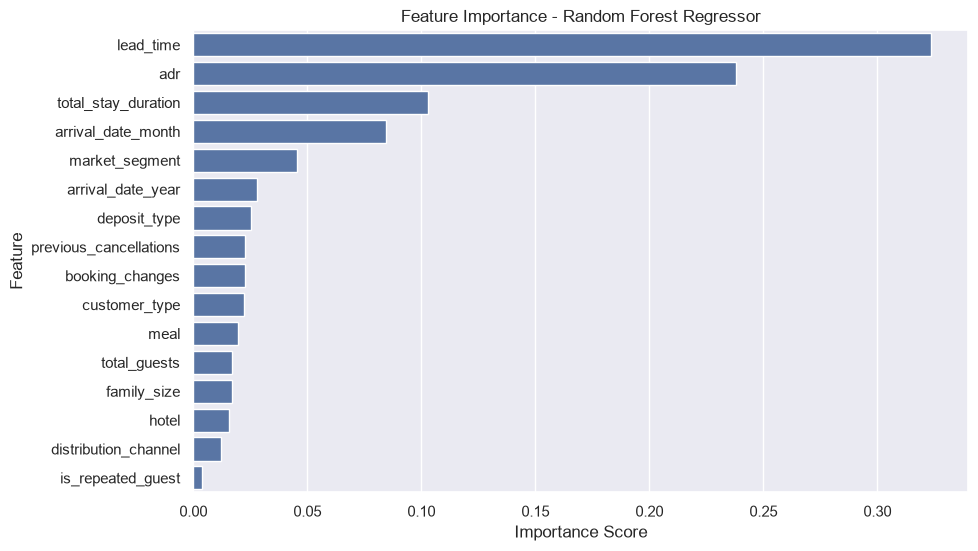

In [55]:
# Get feature importance
feature_importance = forest_model.feature_importances_

# Create a DataFrame
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importance
})

# Sort from most to least important
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the important features
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    order=importance_df['Feature']
)

plt.title('Feature Importance - Random Forest Regressor')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

The feature importance analysis shows that **lead_time** is the most influential feature in predicting hotel booking cancellations, with an importance score of approximately **0.328*. This supports the earlier EDA finding that bookings made further in advance tend to have higher cancellation rates.

The second most important feature is **adr** (Average Daily Rate), with an importance of approximately **0.24**, indicating that the price associated with a booking plays a significant role in distinguishing between cancelled and non-cancelled reservations. **total_stay_duration** is the third most important feature at around **0.10**, suggesting that the length of a customer's planned stay also contributes meaningfully to cancellation predictions.

**arrival_date_month** follows with an importance of about **0.08**, reinforcing the presence of seasonal patterns in cancellation behavior. Other variables such as **market_segment, arrival_date_year, deposit_type, previous_cancellations, booking_changes, and customer_type** have smaller but still useful contributions.

At the lower end, **meal, total_guests, family_size, hotel, distribution_channel, and is_repeated_guest** have relatively low importance scores. This does not necessarily mean that these variables have no relationship with cancellations; rather, they contribute less to the Random Forest's predictive decisions compared with the dominant features.